<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  200 non-null    float64
 1   marks        200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


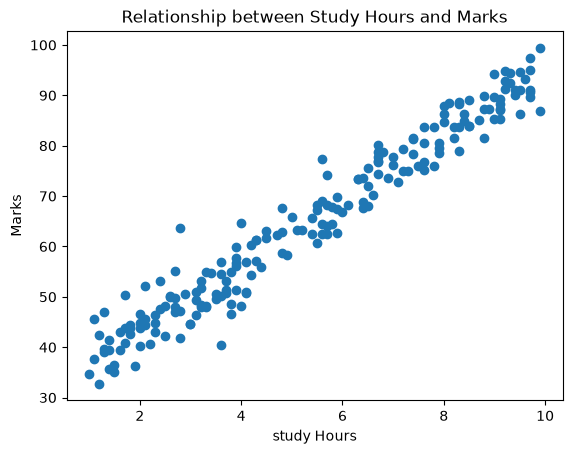

shape of X: (200, 1)
shape of y: (200, 1)
shape of X_train: (160, 1)
shape of y_train: (160, 1)
shape of X_test: (40, 1)
shape of y_test: (40, 1)
60.55753832


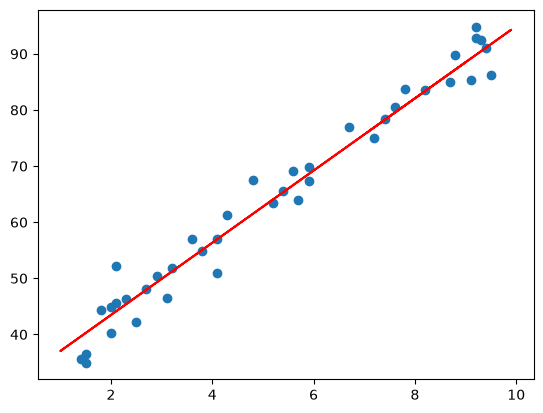

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
#DATA GENERATION
np.random.seed(42)
study_hours = np.random.uniform(1.0,10.0,200).round(1)
marks = (30+(study_hours*6.5)+np.random.normal(0,4,200))
marks = np.clip(marks,0,100)
df = pd.DataFrame({'study_hours':study_hours,'marks':marks})
df.to_csv('student_data.csv',index=False)
df = pd.read_csv("student_data.csv")
df.head(3)
df.tail(3)
df.shape
df.info()
df.describe()
plt.scatter(x = df.study_hours, y = df.marks)
plt.xlabel("study Hours")
plt.ylabel("Marks")
plt.title("Relationship between Study Hours and Marks")
plt.show()
#DATA CLEANING
df.isnull().sum()
df.mean()
df2 = df.fillna(df.mean())
df2.head(3)
#SPLIT DATASET 
X = df2.drop("marks",axis=1)
y = df2.drop("study_hours",axis=1)
print("shape of X:",X.shape)
print("shape of y:",y.shape)
#TEST MODEL
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=49)
print("shape of X_train:",X_train.shape)
print("shape of y_train:",y_train.shape)
print("shape of X_test:",X_test.shape)
print("shape of y_test:",y_test.shape)
#TRAIN MODEL y=m*x+c
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
lr.coef_
lr.intercept_
m = 6.85710188
c = 33.1291308
y = m * 4 + c
print(y)
lr.predict(pd.DataFrame([[4]],columns=["study_hours"]))[0][0]
y_pred = lr.predict(X_test)
pd.DataFrame(np.c_[X_test,y_test,y_pred],columns=["study_hours","marks_actual","marks_predicted"])
lr.score(X_test,y_test)
plt.scatter(X_test,y_test)
plt.plot(X_train,lr.predict(X_train),color="r")

In [3]:
#SAVE ML MODEL
import joblib
joblib.dump(lr, "students_marks_predictor.joblib")

['students_marks_predictor.joblib']